# Phase 4: Bilateral Market-Making vs Baseline Comparison

This notebook trains a bilateral market-making RL agent and compares it against a simple baseline.

**Workflow**:
1. Setup environment and dependencies
2. Clone/pull latest code from repository
3. Implement SymmetricFixedSpread baseline agent
4. Train bilateral RL agent (200 iterations, quick config)
5. Evaluate bilateral agent (1000 episodes)
6. Evaluate baseline agent (1000 episodes)
7. Compare metrics and visualize results

**Runtime**: ~30-40 minutes (GPU)

---

## Step 0: Clear cache and setup repository


In [24]:
# Colab-only clone step (safe no-op locally, no notebook magics needed)
import os
import subprocess

if 'IN_COLAB' not in globals():
    IN_COLAB = False

if IN_COLAB:
    target = "/content/rtle_parallelized"
    if not os.path.exists(target):
        subprocess.run(["git", "clone", "https://github.com/SalmanSattar24/rtle_parallelized.git", target], check=True)
    os.chdir(target)
    print(f"[OK] Colab repo ready at: {target}")
else:
    print("[INFO] Local runtime detected; skipping Colab clone cell.")

[OK] Colab repo ready at: /content/rtle_parallelized


## Step 1: Setup Environment

In [2]:
# OPTIONAL: Mount Google Drive for persistent checkpointing
# This ensures you don't lose your model if Colab disconnects.
import os

try:
    import google.colab  # type: ignore
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    CHECKPOINT_DIR = "/content/drive/MyDrive/mm_rl_checkpoints"
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    print(f"[OK] Google Drive mounted. Checkpoints will be saved to: {CHECKPOINT_DIR}")
except Exception as e:
    CHECKPOINT_DIR = "./checkpoints"
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    print(f"[INFO] Using local checkpoints folder: {CHECKPOINT_DIR} ({e})")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[OK] Google Drive mounted. Checkpoints will be saved to: /content/drive/MyDrive/mm_rl_checkpoints


In [25]:
# Install dependencies (Colab)
import sys
import subprocess

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("[INFO] Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("[INFO] Running locally")

# Install dependencies if in Colab
if IN_COLAB:
    print("\n[INSTALL] Installing PyTorch and dependencies...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch", "gymnasium", "tensorboard", "tyro"])
    print("[OK] Dependencies installed")
else:
    print("[CHECK] Verifying dependencies...")
    try:
        import torch
        import gymnasium
        import tensorboard
        print("[OK] All dependencies present")
    except ImportError as e:
        print(f"[WARNING] Missing dependency: {e}")

[INFO] Running in Google Colab

[INSTALL] Installing PyTorch and dependencies...
[OK] Dependencies installed


## Step 2: Clone/Pull Repository

In [4]:
import os
import subprocess
import shutil

# Setup directory paths
if IN_COLAB:
    # Clone to /content in Colab
    repo_dir = "/content/rtle_parallelized"
    if os.path.exists(repo_dir):
        print(f"[PULL] Updating existing repo at {repo_dir}")
        os.chdir(repo_dir)
        subprocess.run(["git", "pull"], check=True, capture_output=True)
    else:
        print(f"[CLONE] Cloning repository to {repo_dir}")
        subprocess.run(
            ["git", "clone", "https://github.com/SalmanSattar24/rtle_parallelized.git", repo_dir],
            check=True,
            capture_output=True
        )
else:
    # Local path
    repo_dir = "C:/All-Code/CSCI-566/rtle_parallelized"
    print(f"[INFO] Using local repository at {repo_dir}")
    if os.path.exists(os.path.join(repo_dir, ".git")):
        os.chdir(repo_dir)
        print("[PULL] Updating repository...")
        subprocess.run(["git", "pull"], capture_output=True)

os.chdir(repo_dir)
print(f"\n[OK] Working directory: {os.getcwd()}")
print(f"[VERIFY] Repository structure:")
for folder in ["simulation", "rl_files", "tests", "limit_order_book"]:
    path = os.path.join(repo_dir, folder)
    print(f"  {'[OK]' if os.path.exists(path) else '[MISS]'} {folder}/")

[PULL] Updating existing repo at /content/rtle_parallelized

[OK] Working directory: /content/rtle_parallelized
[VERIFY] Repository structure:
  [OK] simulation/
  [OK] rl_files/
  [OK] tests/
  [OK] limit_order_book/


## Step 3.5: Update Repository to Latest Version

In [5]:
print("=" * 70)
print("STEP 3.5: Updating Repository to Latest Version")
print("=" * 70)

print("\nFetching latest commits from GitHub...")
import subprocess
subprocess.run(["git", "pull", "origin", "master"], cwd=repo_dir, check=True)

print("\nâœ“ Repository updated!")
print("=" * 70)


STEP 3.5: Updating Repository to Latest Version

Fetching latest commits from GitHub...

âœ“ Repository updated!


In [6]:
# Sync guard: verify runtime commit before expensive runs
import subprocess
from pathlib import Path

repo_path = Path(repo_dir)
current_commit = None
current_branch = None
expected_commit = None

try:
    current_commit = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], cwd=repo_path).decode().strip()
    current_branch = subprocess.check_output(["git", "rev-parse", "--abbrev-ref", "HEAD"], cwd=repo_path).decode().strip()
    print(f"[GIT] Branch: {current_branch}")
    print(f"[GIT] Commit: {current_commit}")
except Exception as e:
    print(f"[WARN] Could not read current git commit: {e}")

# Auto-derive expected commit from origin/master so no manual pin is required.
try:
    subprocess.run(["git", "fetch", "origin", "master", "--quiet"], cwd=repo_path, check=False)
    expected_commit = subprocess.check_output(["git", "rev-parse", "--short", "origin/master"], cwd=repo_path).decode().strip()
except Exception as e:
    print(f"[WARN] Could not read origin/master commit: {e}")

EXPECTED_COMMIT = expected_commit  # Exposed variable for transparency / downstream use

if current_commit is not None and expected_commit is not None:
    if current_commit == expected_commit:
        print(f"[OK] Repo is up-to-date with origin/master ({expected_commit})")
    else:
        print(
            f"[WARN] Local commit ({current_commit}) differs from origin/master ({expected_commit}). "
            "Run Step 3.5 again before long training/eval."
        )
else:
    print("[INFO] Commit sync check skipped (could not determine local or remote commit).")

[GIT] Branch: master
[GIT] Commit: b03355a
[OK] Repo is up-to-date with origin/master (b03355a)


In [7]:
import numpy as np

print("=" * 70)
print("PHASE 6: AVELLANEDA-STOIKOV (AS) BASELINE CALCULATION")
print("=" * 70)

def compute_as_quotes(mid_price, inventory, time_left, sigma=2.0, gamma=0.1, k=1.5):
    # reservation_price = mid_price - q * gamma * sigma^2 * (T - t)
    # spread = (2 / gamma) * ln(1 + gamma / k) + gamma * sigma^2 * (T - t)
    
    res_price = mid_price - inventory * gamma * (sigma**2) * time_left
    spread = (2 / gamma) * np.log(1 + gamma / k) + gamma * (sigma**2) * time_left
    
    bid_price = np.floor(res_price - spread / 2)
    ask_price = np.ceil(res_price + spread / 2)
    
    return bid_price, ask_price

# Example AS quotes
mid = 1000
inv = 5
t_left = 0.5
b, a = compute_as_quotes(mid, inv, t_left)
print(f"[AS TEST] Mid: {mid} | Inv: {inv} | Bid: {b} | Ask: {a} | Spread: {a-b}")


PHASE 6: AVELLANEDA-STOIKOV (AS) BASELINE CALCULATION
[AS TEST] Mid: 1000 | Inv: 5 | Bid: 998.0 | Ask: 1000.0 | Spread: 2.0


## Step 4: Import Libraries and Setup Paths

In [8]:
import sys
import os
import numpy as np
import torch
import torch.nn as nn
import time
from typing import Optional, Dict, List, Tuple
import matplotlib.pyplot as plt

# Add paths for imports
sys.path.insert(0, repo_dir)
sys.path.insert(0, os.path.join(repo_dir, "simulation"))
sys.path.insert(0, os.path.join(repo_dir, "rl_files"))
sys.path.insert(0, os.path.join(repo_dir, "limit_order_book"))

# Import core modules
from simulation.market_gym import Market
from rl_files.actor_critic import BilateralAgentLogisticNormal

print("[OK] All imports successful")
print(f"[INFO] Using device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
print("[OK] Random seeds set")

[OK] All imports successful
[INFO] Using device: cuda
[OK] Random seeds set


In [9]:
print("="*70)
print("FORCE FRESH REPO LOAD (clear cached imports)")
print("="*70)

# Force reimport of all modules - clear cached modules
import sys
to_remove = [key for key in sys.modules if 'simulation' in key or 'rl_files' in key or 'limit_order_book' in key]
for key in to_remove:
    del sys.modules[key]

print("[OK] Cleared cached modules")
print("="*70 + "\n")

FORCE FRESH REPO LOAD (clear cached imports)
[OK] Cleared cached modules



## Step 4: Implement SymmetricFixedSpread Baseline Agent

In [10]:
from typing import Tuple

class SymmetricFixedSpreadAgent:
    """
    Baseline market-making agent:
    - Posts 1 lot at best bid (passive buy)
    - Posts 1 lot at best ask (passive sell)
    - Returns TUPLE format to match environment expectations
    - Simple, static strategy
    """

    def __init__(self, action_space_dim: int = 7):
        self.action_space_dim = action_space_dim
        # Action allocation:
        # [market%, L1%, L2%, L3%, L4%, L5%, inactive%]
        # For baseline: 0% market, 100% L1 (1 lot at best)
        self.action = np.zeros(action_space_dim)
        self.action[1] = 1.0  # Place 100% at level 1 (best bid/ask)

    def get_action(self, obs: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """Return fixed action tuple (bid_action, ask_action) regardless of observation.
        
        Both bid and ask use the same allocation (symmetric fixed spread).
        Environment expects tuple of two 7-dim arrays.
        """
        return self.action.copy(), self.action.copy()

print("[OK] SymmetricFixedSpreadAgent defined (returns tuple format)")

[OK] SymmetricFixedSpreadAgent defined (returns tuple format)


## Step 5: Configuration

In [26]:
# Paper-Faithful Configuration (Cheridito & Weiss 2026)
# Ready for: flow -> strategic progression

# Shared defaults
BASE_CONFIG = {
    'execution_agent': 'rl_agent',
    'volume': 10,                # Paper-faithful volume
    'terminal_time': 150,        # Paper: 150 seconds
    'time_delta': 15,            # Paper: 15s intervals → 10 steps
    'drop_feature': 'drift',     # Paper default
    'inventory_max': 10,         # Tight cap experiment
    'penalty_weight': 0.0,       # No quadratic penalty
}

# Environment presets for this phase
ENV_PROFILES = {
    'flow': {
        **BASE_CONFIG,
        'market_env': 'flow',    # Noise + tactical
        'seed': 42,
    },
    'strategic': {
        **BASE_CONFIG,
        'market_env': 'strategic',  # Strategic market participants
        'seed': 42,
    },
}

# Training schedule preference
TRAIN_ENV_SEQUENCE = ['flow', 'strategic']

def build_configs(active_env: str, train_seed: int = 42, eval_seed: int = 100):
    if active_env not in ENV_PROFILES:
        raise ValueError(f"Unknown env '{active_env}'. Choose from: {list(ENV_PROFILES)}")
    train_cfg = dict(ENV_PROFILES[active_env])
    eval_cfg = dict(ENV_PROFILES[active_env])
    train_cfg['seed'] = int(train_seed)
    eval_cfg['seed'] = int(eval_seed)
    return train_cfg, eval_cfg

def set_active_env(active_env: str, train_seed: int = 42, eval_seed: int = 100):
    global ACTIVE_ENV, TRAIN_CONFIG, EVAL_CONFIG
    ACTIVE_ENV = active_env
    TRAIN_CONFIG, EVAL_CONFIG = build_configs(active_env, train_seed=train_seed, eval_seed=eval_seed)
    print(f"[OK] ACTIVE_ENV set to {ACTIVE_ENV}")
    print(f"[INFO] TRAIN_CONFIG: env={TRAIN_CONFIG['market_env']}, seed={TRAIN_CONFIG['seed']}, volume={TRAIN_CONFIG['volume']}, I_max={TRAIN_CONFIG['inventory_max']}")
    print(f"[INFO] EVAL_CONFIG : env={EVAL_CONFIG['market_env']}, seed={EVAL_CONFIG['seed']}, volume={EVAL_CONFIG['volume']}, I_max={EVAL_CONFIG['inventory_max']}")

# Default phase starts with flow
ACTIVE_ENV = 'flow'
TRAIN_CONFIG, EVAL_CONFIG = build_configs(ACTIVE_ENV, train_seed=42, eval_seed=100)
EVAL_EPISODES = 1000

print(f"[OK] Dual-regime setup ready. Default ACTIVE_ENV={ACTIVE_ENV}")
print(f"[INFO] Planned sequence: {TRAIN_ENV_SEQUENCE}")
print("[TIP] Switch env with: set_active_env('strategic')")


[OK] Dual-regime setup ready. Default ACTIVE_ENV=flow
[INFO] Planned sequence: ['flow', 'strategic']
[TIP] Switch env with: set_active_env('strategic')


## Step 6: Create Market Environment and Agents

In [12]:
print("[SETUP] Creating market environment...")
market_env = Market(TRAIN_CONFIG)
obs, info = market_env.reset(seed=42)

print(f"[INFO] Observation shape: {obs.shape}")
print(f"[INFO] Action space: {market_env.action_space.shape}")

# Create a simple wrapper so BilateralAgentLogisticNormal can work with Market
class EnvWrapper:
    def __init__(self, env):
        self.env = env
        # Add single_observation_space and single_action_space for agent init
        self.single_observation_space = env.observation_space
        self.single_action_space = env.action_space
    
    # Proxy methods to underlying environment
    def reset(self, seed=None):
        return self.env.reset(seed=seed)
    
    def step(self, action):
        return self.env.step(action)

market = EnvWrapper(market_env)

print("\n[SETUP] Creating bilateral RL agent...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bilateral_agent = BilateralAgentLogisticNormal(market).to(device)
print(f"[OK] Bilateral agent on {device}")

print("\n[SETUP] Creating baseline agent...")
baseline_agent = SymmetricFixedSpreadAgent(market_env.action_space.shape[0])
print(f"[OK] Baseline agent ready")

print("\n[SETUP] All agents created successfully")

[SETUP] Creating market environment...
[INFO] Observation shape: (43,)
[INFO] Action space: (7,)

[SETUP] Creating bilateral RL agent...
[OK] Bilateral agent on cuda

[SETUP] Creating baseline agent...
[OK] Baseline agent ready

[SETUP] All agents created successfully


## Step 7: Train Bilateral Agent


In [13]:
def project_action_quota(x_orig, current_inv, side="bid", inventory_max=10, q_max_base=10):
    """
    Vectorized Paper-faithful quota projection.
    Supports both scalar and batch inputs (for Vectorized Environments).
    """
    x = x_orig.clone()
    device = x.device

    # Ensure current_inv is a tensor and has shape (batch, 1)
    if not isinstance(current_inv, torch.Tensor):
        current_inv = torch.tensor(current_inv, device=device, dtype=torch.float32)

    # Handle scalar or vector current_inv
    if current_inv.dim() == 0:
        current_inv = current_inv.unsqueeze(0)
    if current_inv.dim() == 1:
        current_inv = current_inv.unsqueeze(1)

    if side == "bid":
        room = torch.maximum(torch.zeros_like(current_inv), inventory_max - current_inv)
    else:  # ask
        room = torch.maximum(torch.zeros_like(current_inv), inventory_max + current_inv)

    q_max = torch.minimum(torch.tensor(float(q_max_base), device=device), room)

    # Identify environments with NO room (force 'hold' action)
    no_room_mask = (q_max <= 1e-4).squeeze()
    if torch.any(no_room_mask):
        if x.dim() > 1:
            x[no_room_mask, :-1] = 0.0
            x[no_room_mask, -1] = 1.0
        else:
            x[:-1] = 0.0
            x[-1] = 1.0

    # Scale active mass (non-hold buckets) proportional to quota
    volume = 10.0  # Must match TRAIN_CONFIG['volume']
    active_mass_limit = q_max / volume

    active_mass = torch.sum(x[..., :-1], dim=-1, keepdim=True)
    scale = torch.minimum(torch.ones_like(active_mass), active_mass_limit / (active_mass + 1e-8))

    x[..., :-1] *= scale

    # Final hard cleanup: finite + non-negative + simplex
    x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x = torch.clamp(x, min=0.0)

    total = torch.sum(x, dim=-1, keepdim=True)
    if x.dim() == 1:
        if (not torch.isfinite(total).all()) or total.item() <= 1e-8:
            x[:] = 0.0
            x[-1] = 1.0
        else:
            x = x / total
    else:
        bad_mask = (~torch.isfinite(total.squeeze(-1))) | (total.squeeze(-1) <= 1e-8)
        x = x / (total + 1e-8)
        if torch.any(bad_mask):
            x[bad_mask, :-1] = 0.0
            x[bad_mask, -1] = 1.0

    # Final renorm for numerical tightness
    x = x / (torch.sum(x, dim=-1, keepdim=True) + 1e-8)
    return x

print("[OK] Vectorized Quota Projection loaded.")

[OK] Vectorized Quota Projection loaded.


In [27]:
import copy
import os
import gymnasium as gym

print("=" * 70)
print("STEP 7A: VECTORIZED TRAINING SETUP")
print("=" * 70)

# PPO / rollout hyperparameters
# Auto-scale env count based on hardware, with optional manual override.
NUM_ENVS_OVERRIDE = None  # e.g., set to 8/12/16 to force a value
CPU_CORES = max(1, int(os.cpu_count() or 1))
GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
GPU_NAME_UPPER = GPU_NAME.upper()

if NUM_ENVS_OVERRIDE is not None:
    NUM_ENVS = int(NUM_ENVS_OVERRIDE)
else:
    if torch.cuda.is_available():
        if "L4" in GPU_NAME_UPPER:
            suggested_envs = 16
        elif "T4" in GPU_NAME_UPPER:
            suggested_envs = 12
        else:
            suggested_envs = 8
    else:
        suggested_envs = 4

    # Market stepping is CPU-heavy, but notebook runtimes often report very low core counts.
    # Allow mild oversubscription so T4/L4 sessions can still parallelize meaningfully.
    if CPU_CORES <= 2:
        cpu_cap = 4
    elif CPU_CORES <= 4:
        cpu_cap = 8
    else:
        cpu_cap = CPU_CORES * 2

    NUM_ENVS = max(1, min(suggested_envs, cpu_cap))

STEPS_PER_ROLLOUT = 64
NUM_TRAIN_ITERS = 500
BASE_LR = 2e-4
GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP_COEF = 0.2
VF_COEF = 0.5
MAX_GRAD_NORM = 0.5
ent_coef = 0.05
UPDATE_EPOCHS = 4

BATCH_SIZE = NUM_ENVS * STEPS_PER_ROLLOUT
MINIBATCH_SIZE = min(256, BATCH_SIZE)

# Async workers have been fragile in this notebook context; default to sync.
USE_ASYNC_VECTOR = False

class VectorMarketWrapper(gym.Env):
    metadata = {}

    def __init__(self, cfg):
        super().__init__()
        self.m = Market(cfg)
        self.observation_space = self.m.observation_space
        # Flatten bilateral action tuple into one Box(14,) for vectorized stepping
        low = np.concatenate([self.m.action_space.low, self.m.action_space.low]).astype(np.float32)
        high = np.concatenate([self.m.action_space.high, self.m.action_space.high]).astype(np.float32)
        self.action_space = gym.spaces.Box(low=low, high=high, dtype=np.float32)

    def reset(self, *, seed=None, options=None):
        return self.m.reset(seed=seed)

    def step(self, action):
        a = np.asarray(action, dtype=np.float32).reshape(-1)
        bid = a[:7]
        ask = a[7:14]
        return self.m.step((bid, ask))

def make_env(rank):
    def thunk():
        cfg = dict(TRAIN_CONFIG)
        cfg['seed'] = int(TRAIN_CONFIG['seed']) + rank
        return VectorMarketWrapper(cfg)
    return thunk

# Close stale vector env if this cell is rerun.
if 'envs' in globals():
    try:
        envs.close(terminate=True)
    except TypeError:
        # Some vector env implementations do not support terminate kwarg.
        try:
            envs.close()
        except Exception:
            pass
    except Exception:
        pass

ctor = gym.vector.AsyncVectorEnv if USE_ASYNC_VECTOR else gym.vector.SyncVectorEnv
envs = ctor([make_env(i) for i in range(NUM_ENVS)])

optimizer = torch.optim.Adam(bilateral_agent.parameters(), lr=BASE_LR, eps=1e-5)
training_returns = []
training_losses = []
best_val_score = float('-inf')
best_state_dict = copy.deepcopy(bilateral_agent.state_dict())

print(f"[HW] GPU={GPU_NAME} | CPU cores={CPU_CORES}")
print(f"[OK] Vector env ready: {NUM_ENVS} envs | BATCH_SIZE={BATCH_SIZE} | MINIBATCH={MINIBATCH_SIZE}")
print(f"[OK] Vector backend: {'AsyncVectorEnv' if USE_ASYNC_VECTOR else 'SyncVectorEnv'}")
print(f"[OK] Action shape per env: {envs.single_action_space.shape}, obs shape: {envs.single_observation_space.shape}")

STEP 7A: VECTORIZED TRAINING SETUP
[HW] GPU=Tesla T4 | CPU cores=2
[OK] Vector env ready: 4 envs | BATCH_SIZE=256 | MINIBATCH=256
[OK] Vector backend: SyncVectorEnv
[OK] Action shape per env: (14,), obs shape: (43,)


In [ ]:
print("=" * 70)
print("STEP 7: TRAIN BILATERAL AGENT (Hyper-Speed Vectorized PPO)")
print("=" * 70)

print(f"[SPEED] Training optimized for GPU using {NUM_ENVS} parallel environments.")

def sanitize_simplex_batch(x, interior=False, eps=1e-6):
    x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x = torch.clamp(x, min=0.0)
    denom = torch.sum(x, dim=-1, keepdim=True)
    bad = (~torch.isfinite(denom.squeeze(-1))) | (denom.squeeze(-1) <= 1e-8)
    x = x / (denom + 1e-8)
    if torch.any(bad):
        x[bad, :-1] = 0.0
        x[bad, -1] = 1.0
    x = x / (torch.sum(x, dim=-1, keepdim=True) + 1e-8)

    # For PPO log-prob computations with logistic-normal inverse transform,
    # all components must be strictly positive to avoid log(0) -> +/-inf.
    if interior:
        n = x.shape[-1]
        if n > 1:
            floor = min(float(eps), 0.5 / n)
            x = x * (1.0 - floor * n) + floor
            x = x / (torch.sum(x, dim=-1, keepdim=True) + 1e-8)
    return x

# Rolling diagnostics (reset each training run)
training_entropy = []
training_approx_kl = []
training_clipfrac = []
training_update_ratio = []
training_skip_ratio = []
training_value_mean = []
training_bid_hold = []
training_ask_hold = []
training_outlier_flags = []
training_explained_var = []
training_ent_coef = []

# Schedules (linear)
# Paper-based entropy scheduling (Schulman et al. 2017, Haarnoja et al. SAC):
# - Start high to encourage exploration (0.05)
# - Decay to moderate floor (0.01) to maintain some stochasticity
# This prevents both entropy collapse AND premature loss of exploration
ent_coef_start = float(ent_coef)
ent_coef_end = 0.01
var_start = 1.0
var_end = 0.1

# --- Optimization Setup ---
# Reset environments
next_obs, _ = envs.reset()
next_obs = torch.tensor(next_obs, dtype=torch.float32).to(device)
next_done = torch.zeros(NUM_ENVS).to(device)
current_inventory = torch.zeros(NUM_ENVS).to(device)

start_time = time.time()
bilateral_agent.train()

for iteration in range(1, NUM_TRAIN_ITERS + 1):
    is_nan = False
    # Schedules
    frac = (iteration - 1) / NUM_TRAIN_ITERS
    lr_now = BASE_LR * (1.0 - frac)
    optimizer.param_groups[0]["lr"] = lr_now
    ent_coef_now = ent_coef_start + (ent_coef_end - ent_coef_start) * frac

    # Anneal variance if agent supports it
    if hasattr(bilateral_agent, 'set_variance'):
        curr_var_sched = var_start + (var_end - var_start) * frac
        bilateral_agent.set_variance(max(0.05, curr_var_sched))

    # Storage for this rollout
    obs_batch = torch.zeros((STEPS_PER_ROLLOUT, NUM_ENVS) + envs.single_observation_space.shape).to(device)
    bid_batch = torch.zeros((STEPS_PER_ROLLOUT, NUM_ENVS, 7)).to(device)
    ask_batch = torch.zeros((STEPS_PER_ROLLOUT, NUM_ENVS, 7)).to(device)
    logprob_batch = torch.zeros((STEPS_PER_ROLLOUT, NUM_ENVS)).to(device)
    reward_batch = torch.zeros((STEPS_PER_ROLLOUT, NUM_ENVS)).to(device)
    done_batch = torch.zeros((STEPS_PER_ROLLOUT, NUM_ENVS)).to(device)
    value_batch = torch.zeros((STEPS_PER_ROLLOUT, NUM_ENVS)).to(device)

    # --- 1. COLLECT ROLLOUT ---
    for step in range(STEPS_PER_ROLLOUT):
        # Clean obs BEFORE storing in rollout buffer
        next_obs = torch.nan_to_num(next_obs, nan=0.0, posinf=100.0, neginf=-100.0)
        obs_batch[step] = next_obs
        done_batch[step] = next_done

        # Phase G: Safe Agent execution
        with torch.no_grad():
            # Safeguard 1: Weight parity check
            is_nan, p_name = bilateral_agent.check_parameters()
            if is_nan:
                print(f"\n!!! [CRITICAL] Weight corruption in {p_name}. Stopping.")
                break

            # Safeguard 2: Input cleaning
            next_obs = torch.nan_to_num(next_obs, nan=0.0, posinf=100.0, neginf=-100.0)

            # Safeguard 3: Safe distribution initialization logic
            try:
                (bid, ask), log_prob, _, value = bilateral_agent.get_action_and_value(next_obs)
            except Exception as e:
                print(f" (Step {step} numerical skip: {e}) ", end="")
                bid = torch.zeros((NUM_ENVS, 7), device=device)
                ask = torch.zeros((NUM_ENVS, 7), device=device)
                bid[:, -1] = 1.0
                ask[:, -1] = 1.0
                log_prob = torch.zeros(NUM_ENVS, device=device)
                value = torch.zeros(NUM_ENVS, device=device)

            # Mask/Quota projection (strictly required for RL)
            bid = project_action_quota(bid, current_inventory, side="bid")
            ask = project_action_quota(ask, current_inventory, side="ask")

            # Hard finite/simplex sanitation (for env step)
            bid = sanitize_simplex_batch(bid, interior=False)
            ask = sanitize_simplex_batch(ask, interior=False)

            # Re-collect logprobs for masked/projected actions.
            # Use interiorized simplex only for log-prob inversion stability.
            try:
                bid_lp = sanitize_simplex_batch(bid, interior=True)
                ask_lp = sanitize_simplex_batch(ask, interior=True)
                _, log_prob, _, _ = bilateral_agent.get_action_and_value(next_obs, action=(bid_lp, ask_lp))
                if not torch.isfinite(log_prob).all():
                    log_prob = torch.zeros(NUM_ENVS, device=device)
            except Exception:
                log_prob = torch.zeros(NUM_ENVS, device=device)

        # Values & Logging storage
        value_batch[step] = torch.nan_to_num(value.flatten(), nan=0.0, posinf=0.0, neginf=0.0)
        bid_batch[step] = bid
        ask_batch[step] = ask
        logprob_batch[step] = torch.nan_to_num(log_prob, nan=0.0, posinf=0.0, neginf=0.0)

        # STEP ENV
        env_action = np.concatenate([bid.cpu().numpy(), ask.cpu().numpy()], axis=1)
        next_obs_np, rewards, terms, truncs, infos = envs.step(env_action)

        reward_batch[step] = torch.nan_to_num(torch.tensor(rewards).to(device).view(-1), nan=0.0, posinf=0.0, neginf=0.0)
        next_obs = torch.tensor(next_obs_np, dtype=torch.float32).to(device)
        next_done = torch.tensor(np.logical_or(terms, truncs), dtype=torch.float32).to(device)

        # Track current inventory per env for next quota projection
        if "net_inventory" in infos:
            current_inventory = torch.tensor(infos["net_inventory"]).to(device)
        else:
            # Multi-process info structure handling
            current_inventory = torch.tensor([i.get("net_inventory", 0) for i in infos.get("final_info", [{} for _ in range(NUM_ENVS)])]).to(device)

    if is_nan:
        break  # Outer loop break if corrupted

    # --- 2. COMPUTE ADVANTAGES (GAE) ---
    with torch.no_grad():
        next_value = bilateral_agent.get_value(torch.nan_to_num(next_obs, nan=0.0, posinf=100.0, neginf=-100.0)).reshape(1, -1)
        next_value = torch.nan_to_num(next_value, nan=0.0, posinf=0.0, neginf=0.0)

        advantages = torch.zeros_like(reward_batch).to(device)
        lastgaelam = 0
        for t in reversed(range(STEPS_PER_ROLLOUT)):
            if t == STEPS_PER_ROLLOUT - 1:
                nextnonterminal = 1.0 - next_done
                nextvalues = next_value
            else:
                nextnonterminal = 1.0 - done_batch[t + 1]
                nextvalues = value_batch[t + 1]
            delta = reward_batch[t] + GAMMA * nextvalues * nextnonterminal - value_batch[t]
            delta = torch.nan_to_num(delta, nan=0.0, posinf=0.0, neginf=0.0)
            advantages[t] = lastgaelam = delta + GAMMA * GAE_LAMBDA * nextnonterminal * lastgaelam
        advantages = torch.nan_to_num(advantages, nan=0.0, posinf=0.0, neginf=0.0)
        returns = torch.nan_to_num(advantages + value_batch, nan=0.0, posinf=0.0, neginf=0.0)

    # --- 3. OPTIMIZE POLICY & VALUE ---
    # Flatten batches
    b_obs = torch.nan_to_num(obs_batch.reshape((-1,) + envs.single_observation_space.shape), nan=0.0, posinf=100.0, neginf=-100.0)
    b_logprobs = torch.nan_to_num(logprob_batch.reshape(-1), nan=0.0, posinf=0.0, neginf=0.0)
    b_bid = sanitize_simplex_batch(bid_batch.reshape((-1, 7)), interior=True)
    b_ask = sanitize_simplex_batch(ask_batch.reshape((-1, 7)), interior=True)
    b_advantages = torch.nan_to_num(advantages.reshape(-1), nan=0.0, posinf=0.0, neginf=0.0)
    b_returns = torch.nan_to_num(returns.reshape(-1), nan=0.0, posinf=0.0, neginf=0.0)

    # Explained variance diagnostic (critic quality)
    with torch.no_grad():
        v_pred = torch.nan_to_num(value_batch.reshape(-1), nan=0.0, posinf=0.0, neginf=0.0)
        v_tgt = b_returns
        var_tgt = torch.var(v_tgt, unbiased=False)
        if torch.isfinite(var_tgt) and var_tgt > 1e-8:
            explained_var = float((1.0 - torch.var(v_tgt - v_pred, unbiased=False) / var_tgt).item())
        else:
            explained_var = float('nan')

    inds = np.arange(BATCH_SIZE)
    last_loss = float('nan')
    update_steps = 0
    skipped_nonfinite = 0
    mb_entropies = []
    mb_kls = []
    mb_clipfracs = []

    for epoch in range(UPDATE_EPOCHS):
        np.random.shuffle(inds)
        for start in range(0, BATCH_SIZE, MINIBATCH_SIZE):
            end = start + MINIBATCH_SIZE
            mb_inds = inds[start:end]

            _, newlogprob, entropy, newvalue = bilateral_agent.get_action_and_value(
                b_obs[mb_inds], action=(b_bid[mb_inds], b_ask[mb_inds])
            )

            if (not torch.isfinite(newlogprob).all()) or (not torch.isfinite(newvalue).all()):
                skipped_nonfinite += 1
                continue

            logratio = torch.nan_to_num(newlogprob - b_logprobs[mb_inds], nan=0.0, posinf=0.0, neginf=0.0)
            ratio = torch.exp(torch.clamp(logratio, min=-20.0, max=20.0))

            # PPO diagnostics
            approx_kl = torch.nan_to_num(((ratio - 1.0) - logratio).mean(), nan=0.0, posinf=0.0, neginf=0.0)
            clipfrac = torch.nan_to_num(((ratio - 1.0).abs() > CLIP_COEF).float().mean(), nan=0.0, posinf=0.0, neginf=0.0)
            mb_kls.append(float(approx_kl.item()))
            mb_clipfracs.append(float(clipfrac.item()))
            mb_entropies.append(float(torch.nan_to_num(entropy.mean(), nan=0.0, posinf=0.0, neginf=0.0).item()))

            # Policy loss
            mb_advantages = torch.nan_to_num(b_advantages[mb_inds], nan=0.0, posinf=0.0, neginf=0.0)
            adv_std = mb_advantages.std()
            if torch.isfinite(adv_std) and adv_std > 1e-8:
                mb_advantages = (mb_advantages - mb_advantages.mean()) / (adv_std + 1e-8)
            else:
                mb_advantages = mb_advantages - mb_advantages.mean()

            pg_loss1 = -mb_advantages * ratio
            pg_loss2 = -mb_advantages * torch.clamp(ratio, 1 - CLIP_COEF, 1 + CLIP_COEF)
            pg_loss = torch.max(pg_loss1, pg_loss2).mean()

            # Value loss
            newvalue = newvalue.view(-1)
            target_returns = torch.nan_to_num(b_returns[mb_inds], nan=0.0, posinf=0.0, neginf=0.0)
            v_loss = 0.5 * ((newvalue - target_returns) ** 2).mean()

            # Entropy loss
            entropy_loss = torch.nan_to_num(entropy.mean(), nan=0.0, posinf=0.0, neginf=0.0)

            loss = pg_loss - ent_coef_now * entropy_loss + v_loss * VF_COEF
            if not torch.isfinite(loss):
                skipped_nonfinite += 1
                continue

            # Optimizer step
            optimizer.zero_grad()
            loss.backward()

            grad_finite = True
            for p in bilateral_agent.parameters():
                if p.grad is not None and (not torch.isfinite(p.grad).all()):
                    grad_finite = False
                    break
            if not grad_finite:
                optimizer.zero_grad()
                skipped_nonfinite += 1
                continue

            nn.utils.clip_grad_norm_(bilateral_agent.parameters(), MAX_GRAD_NORM)
            optimizer.step()
            last_loss = float(loss.item())
            update_steps += 1

    if update_steps == 0:
        last_loss = 0.0

    # --- 4. LOGGING & DIAGNOSTICS ---
    avg_reward = float(reward_batch.mean().item())
    value_mean_iter = float(value_batch.mean().item())
    bid_hold = float(bid_batch[..., -1].mean().item())
    ask_hold = float(ask_batch[..., -1].mean().item())
    entropy_mean_iter = float(np.mean(mb_entropies)) if len(mb_entropies) > 0 else float('nan')
    kl_mean_iter = float(np.mean(mb_kls)) if len(mb_kls) > 0 else float('nan')
    clipfrac_mean_iter = float(np.mean(mb_clipfracs)) if len(mb_clipfracs) > 0 else float('nan')

    total_mb = UPDATE_EPOCHS * int(np.ceil(BATCH_SIZE / MINIBATCH_SIZE))
    update_ratio = float(update_steps) / float(max(1, total_mb))
    skip_ratio = float(skipped_nonfinite) / float(max(1, total_mb))

    training_returns.append(avg_reward)
    training_losses.append(last_loss)
    training_entropy.append(entropy_mean_iter)
    training_approx_kl.append(kl_mean_iter)
    training_clipfrac.append(clipfrac_mean_iter)
    training_update_ratio.append(update_ratio)
    training_skip_ratio.append(skip_ratio)
    training_value_mean.append(value_mean_iter)
    training_bid_hold.append(bid_hold)
    training_ask_hold.append(ask_hold)
    training_explained_var.append(explained_var)
    training_ent_coef.append(float(ent_coef_now))

    tail_n = min(20, len(training_returns))
    tail_returns = np.asarray(training_returns[-tail_n:], dtype=np.float64)
    reward_avg20 = float(np.mean(tail_returns))
    reward_std20 = float(np.std(tail_returns))
    cvar_k = max(1, int(np.ceil(0.2 * tail_n)))
    cvar20 = float(np.mean(np.sort(tail_returns)[:cvar_k]))
    outlier_threshold = reward_avg20 - 2.0 * max(reward_std20, 1e-8)
    outlier_flag = 1.0 if avg_reward < outlier_threshold else 0.0
    training_outlier_flags.append(outlier_flag)
    outlier_rate20 = float(np.mean(training_outlier_flags[-tail_n:]))

    ent_tail_n = min(20, len(training_entropy))
    ent_tail = np.asarray(training_entropy[-ent_tail_n:], dtype=np.float64)
    entropy_avg20 = float(np.nanmean(ent_tail)) if ent_tail_n > 0 else float('nan')

    # Save Best Model Logic
    if avg_reward > best_val_score:
        best_val_score = avg_reward
        best_state_dict = copy.deepcopy(bilateral_agent.state_dict())
        torch.save(best_state_dict, os.path.join(CHECKPOINT_DIR, "best_model.pth"))

    if iteration % 1 == 0:
        elapsed = time.time() - start_time
        curr_var = float(getattr(bilateral_agent, 'variance', float('nan'))) if hasattr(bilateral_agent, 'variance') else float('nan')
        print(
            f"[{iteration:03d}/{NUM_TRAIN_ITERS}] "
            f"R: {avg_reward:7.4f} | R20: {reward_avg20:7.4f} | Std20: {reward_std20:6.4f} | CVaR20: {cvar20:7.4f} | "
            f"Loss: {last_loss:7.4f} | Ent: {entropy_mean_iter:6.3f} | Ent20: {entropy_avg20:6.3f} | "
            f"KL: {kl_mean_iter:7.5f} | Clip: {clipfrac_mean_iter:5.1%} | "
            f"Upd: {update_steps:2d}/{total_mb:2d} ({update_ratio:5.1%}) | Skip: {skipped_nonfinite:2d} ({skip_ratio:5.1%}) | "
            f"Hold(b/a): {bid_hold:4.2f}/{ask_hold:4.2f} | Vmean: {value_mean_iter:7.4f} | EV: {explained_var:6.3f} | "
            f"Var: {curr_var:5.3f} | EntC: {ent_coef_now:6.4f} | Out20: {outlier_rate20:4.2f} | Time: {elapsed:5.1f}s"
        )

    # Regular Checkpoint
    if iteration % 10 == 0:
        torch.save(bilateral_agent.state_dict(), os.path.join(CHECKPOINT_DIR, "checkpoint_last.pth"))

print(f"\n[OK] Training Complete in {time.time() - start_time:.2f}s")

STEP 7: TRAIN BILATERAL AGENT (Hyper-Speed Vectorized PPO)
[SPEED] Training optimized for GPU using 4 parallel environments.
[001/200] R: -0.0250 | R20: -0.0250 | Std20: 0.0000 | CVaR20: -0.0250 | Loss:  0.0332 | Ent: 17.027 | Ent20: 17.027 | KL: 2555.83392 | Clip: 17.5% | Upd:  4/ 4 (100.0%) | Skip:  0 ( 0.0%) | Hold(b/a): 0.11/0.17 | Vmean:  0.5358 | EV: -1.766 | Var: 1.000 | EntC: 0.0100 | Out20: 0.00 | Time:  11.3s
[002/200] R: -0.0438 | R20: -0.0344 | Std20: 0.0094 | CVaR20: -0.0438 | Loss:  0.0392 | Ent: 16.973 | Ent20: 17.000 | KL: 0.25874 | Clip: 12.8% | Upd:  4/ 4 (100.0%) | Skip:  0 ( 0.0%) | Hold(b/a): 0.10/0.18 | Vmean:  0.3632 | EV: -1.062 | Var: 0.996 | EntC: 0.0100 | Out20: 0.00 | Time:  22.6s
[003/200] R: -0.0797 | R20: -0.0495 | Std20: 0.0227 | CVaR20: -0.0797 | Loss:  0.0435 | Ent: 16.919 | Ent20: 16.973 | KL: 0.10026 | Clip: 16.0% | Upd:  4/ 4 (100.0%) | Skip:  0 ( 0.0%) | Hold(b/a): 0.10/0.18 | Vmean: -0.0318 | EV: -0.666 | Var: 0.991 | EntC: 0.0099 | Out20: 0.00 | 

## Step 8: Evaluate Bilateral Agent (Final Best Model)
# This performs a large-scale evaluation of the trained agent to compare against baseline.


In [16]:
import torch
import numpy as np

print("=" * 70)
print("STEP 8: EVALUATE BILATERAL AGENT (RL)")
print("=" * 70)

# Ensure best weights are loaded (redundant but safe)
if 'best_state_dict' in locals():
    bilateral_agent.load_state_dict(best_state_dict)

def sanitize_np_simplex(a: np.ndarray) -> np.ndarray:
    a = np.asarray(a, dtype=np.float64)
    a = np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)
    a = np.clip(a, 0.0, None)
    s = float(np.sum(a))
    if (not np.isfinite(s)) or s <= 1e-8:
        out = np.zeros_like(a, dtype=np.float64)
        out[-1] = 1.0
        return out.astype(np.float32)
    return (a / s).astype(np.float32)

def sanitize_eval_action(action_tensor, side, current_inventory):
    a = project_action_quota(
        action_tensor,
        current_inventory,
        side=side,
        inventory_max=EVAL_CONFIG['inventory_max']
    )
    a = torch.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)
    a = torch.clamp(a, min=0.0)
    denom = torch.sum(a, dim=-1, keepdim=True)
    bad = (~torch.isfinite(denom.squeeze(-1))) | (denom.squeeze(-1) <= 1e-8)
    a = a / (denom + 1e-8)
    if torch.any(bad):
        a[bad, :-1] = 0.0
        a[bad, -1] = 1.0
    a = a / (torch.sum(a, dim=-1, keepdim=True) + 1e-8)
    return a

EVAL_EPISODES = 1000
bilateral_returns = []
bilateral_inventories = []

for i in range(EVAL_EPISODES):
    cfg = dict(EVAL_CONFIG)
    cfg['seed'] = 50000 + i
    m_raw = Market(cfg)
    market_wrap = EnvWrapper(m_raw)
    obs, _ = market_wrap.reset()
    ep_ret = 0.0
    current_inventory = 0

    while True:
        obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            # Evaluation uses DETERMINISTIC actions
            bid_action, ask_action = bilateral_agent.deterministic_action(obs_tensor)

            # Quota projection + hard sanitization
            bid_action = sanitize_eval_action(bid_action, side="bid", current_inventory=current_inventory)
            ask_action = sanitize_eval_action(ask_action, side="ask", current_inventory=current_inventory)

            bid_np = sanitize_np_simplex(bid_action[0].cpu().numpy())
            ask_np = sanitize_np_simplex(ask_action[0].cpu().numpy())
            env_action = (bid_np, ask_np)

        obs, reward, terminated, truncated, info = market_wrap.step(env_action)
        ep_ret += float(reward)
        current_inventory = info.get("net_inventory", 0)

        if terminated or truncated:
            break

    bilateral_returns.append(ep_ret)
    bilateral_inventories.append(abs(current_inventory))

    if (i + 1) % 200 == 0:
        print(f"[{i+1:4d}/{EVAL_EPISODES}] Mean return: {np.mean(bilateral_returns):.4f} | Abs Inv: {np.mean(bilateral_inventories):.4f}")

bilateral_returns = np.array(bilateral_returns)
bilateral_inventories = np.array(bilateral_inventories)

print(f"\n[OK] RL Evaluation complete: {np.mean(bilateral_returns):.4f} +/- {np.std(bilateral_returns):.4f}")

STEP 8: EVALUATE BILATERAL AGENT (RL)
[ 200/1000] Mean return: -0.3815 | Abs Inv: 10.0000
[ 400/1000] Mean return: -0.3908 | Abs Inv: 10.0000
[ 600/1000] Mean return: -0.3850 | Abs Inv: 10.0000
[ 800/1000] Mean return: -0.3850 | Abs Inv: 10.0000
[1000/1000] Mean return: -0.3809 | Abs Inv: 10.0000

[OK] RL Evaluation complete: -0.3809 +/- 0.8060


## Step 9: Evaluate Baseline Agent


In [17]:
print("=" * 70)
print(f"STEP 9: EVALUATE BASELINE (Fixed Spread)")
print("=" * 70)

baseline_agent = SymmetricFixedSpreadAgent(action_space_dim=market_env.action_space.shape[0])
baseline_returns = []
baseline_inventories = []

for i in range(EVAL_EPISODES):
    cfg = dict(EVAL_CONFIG)
    cfg['seed'] = 50000 + i
    m_raw = Market(cfg)
    market_wrap = EnvWrapper(m_raw)
    obs, _ = market_wrap.reset()
    ep_ret = 0.0
    current_inventory = 0
    
    while True:
        action = baseline_agent.get_action(obs)
        obs, reward, terminated, truncated, info = market_wrap.step(action)
        ep_ret += float(reward)
        current_inventory = info.get("net_inventory", 0)
        if terminated or truncated:
            break
            
    baseline_returns.append(ep_ret)
    baseline_inventories.append(abs(current_inventory))

baseline_returns = np.array(baseline_returns)
baseline_inventories = np.array(baseline_inventories)

print(f"\n[OK] Baseline Evaluation complete: {np.mean(baseline_returns):.4f} +/- {np.std(baseline_returns):.4f}")


STEP 9: EVALUATE BASELINE (Fixed Spread)

[OK] Baseline Evaluation complete: -0.6471 +/- 0.9404


## Step 10: Compare Results


In [18]:
# Compute statistics for comparison
import pandas as pd

stats_data = {
    'Metric': ['Mean Return', 'Std Return', 'CVaR (5%)', 'Outliers (<-200)', 'Mean Abs Inv'],
    'Bilateral RL': [
        np.mean(bilateral_returns),
        np.std(bilateral_returns),
        np.mean(np.sort(bilateral_returns)[:max(1, len(bilateral_returns)//20)]),
        np.mean(bilateral_returns < -200.0),
        np.mean(bilateral_inventories)
    ],
    'Baseline': [
        np.mean(baseline_returns),
        np.std(baseline_returns),
        np.mean(np.sort(baseline_returns)[:max(1, len(baseline_returns)//20)]),
        np.mean(baseline_returns < -200.0),
        np.mean(baseline_inventories)
    ]
}

df_stats = pd.DataFrame(stats_data)
display(df_stats.style.background_gradient(subset=['Bilateral RL', 'Baseline'], cmap='RdYlGn'))


,Metric,Bilateral RL,Baseline
0,Mean Return,-0.380900,-0.647100
1,Std Return,0.806018,0.940378
2,CVaR (5%),-2.036000,-2.478000
3,Outliers (<-200),0.000000,0.000000
4,Mean Abs Inv,10.000000,10.000000


## Step 11: Visualize Results

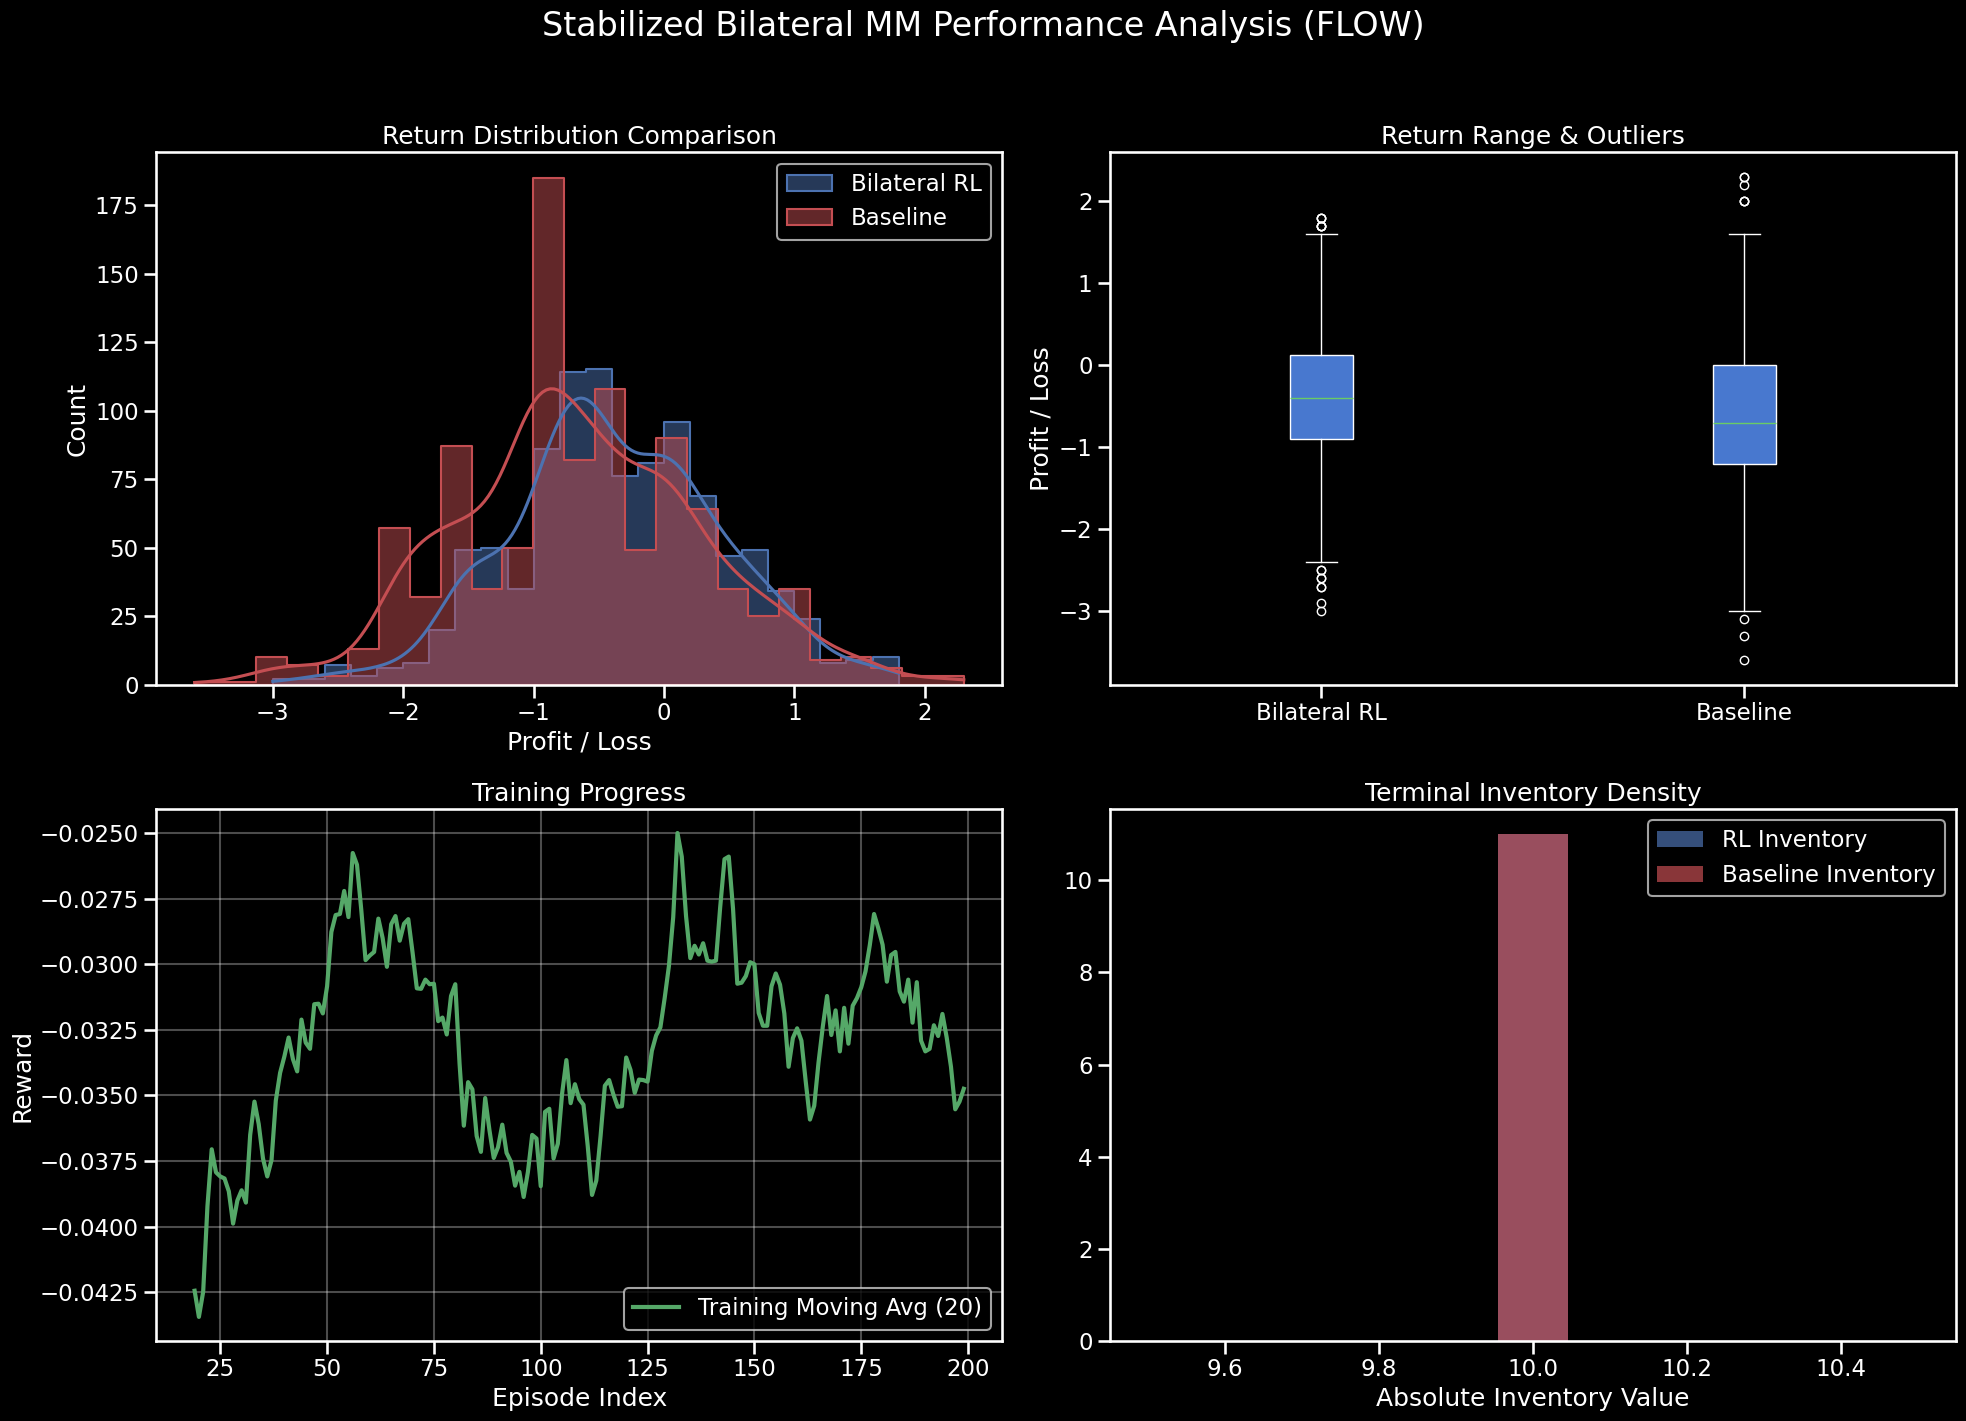

[OK] Performance report and plots generated: bilateral_mm_success_report_flow.png


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set premium aesthetic
plt.style.use('seaborn-v0_8-muted')
sns.set_context("talk")
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
colors = ['#4C72B0', '#C44E52', '#55A868', '#8172B3']

# 1. Return Distributions
sns.histplot(bilateral_returns, ax=axes[0, 0], color=colors[0], label='Bilateral RL', kde=True, element="step")
sns.histplot(baseline_returns, ax=axes[0, 0], color=colors[1], label='Baseline', kde=True, element="step")
axes[0, 0].set_title('Return Distribution Comparison')
axes[0, 0].set_xlabel('Profit / Loss')
axes[0, 0].legend()

# 2. Cumulative Returns (Box Plot)
axes[0, 1].boxplot([bilateral_returns, baseline_returns], tick_labels=['Bilateral RL', 'Baseline'], patch_artist=True)
axes[0, 1].set_title('Return Range & Outliers')
axes[0, 1].set_ylabel('Profit / Loss')

# 3. Training Curve (if training_returns exists)
if 'training_returns' in locals() and len(training_returns) > 0:
    training_ma = pd.Series(training_returns).rolling(window=20).mean()
    axes[1, 0].plot(training_ma, color=colors[2], linewidth=3, label='Training Moving Avg (20)')
    axes[1, 0].set_title('Training Progress')
    axes[1, 0].set_xlabel('Episode Index')
    axes[1, 0].set_ylabel('Reward')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
else:
    axes[1, 0].text(0.5, 0.5, "No training curve data", ha='center')

# 4. Inventory Management
axes[1, 1].hist(bilateral_inventories, bins=11, alpha=0.7, color=colors[0], label='RL Inventory', density=True)
axes[1, 1].hist(baseline_inventories, bins=11, alpha=0.7, color=colors[1], label='Baseline Inventory', density=True)
axes[1, 1].set_title('Terminal Inventory Density')
axes[1, 1].set_xlabel('Absolute Inventory Value')
axes[1, 1].legend()

env_tag = TRAIN_CONFIG.get('market_env', 'unknown')
report_file = f"bilateral_mm_success_report_{env_tag}.png"

plt.suptitle(f"Stabilized Bilateral MM Performance Analysis ({TRAIN_CONFIG['market_env'].upper()})", fontsize=24, y=1.02)
plt.tight_layout()
plt.savefig(report_file, dpi=150, bbox_inches='tight')
plt.show()

print(f"[OK] Performance report and plots generated: {report_file}")

## Step 12: Summary and Next Steps

In [20]:
print("\n" + "="*70)
print("PHASE 4 SIMPLIFIED: EXECUTION COMPLETE")
print("="*70)
print()
print("RESULTS SUMMARY")
print("-" * 70)

# Ensure required stats are defined from available evaluation arrays
if 'bilateral_returns' not in globals() or 'baseline_returns' not in globals():
    raise RuntimeError("Missing evaluation arrays. Please run Step 8 and Step 9 first.")

if 'bilateral_inventories' not in globals() or 'baseline_inventories' not in globals():
    raise RuntimeError("Missing inventory arrays. Please run Step 8 and Step 9 first.")

bilateral_stats = {
    'mean_return': float(np.mean(bilateral_returns)),
    'std_return': float(np.std(bilateral_returns)),
    'mean_inventory': float(np.mean(bilateral_inventories)),
}

baseline_stats = {
    'mean_return': float(np.mean(baseline_returns)),
    'std_return': float(np.std(baseline_returns)),
    'mean_inventory': float(np.mean(baseline_inventories)),
}

improvement = float(bilateral_stats['mean_return'] - baseline_stats['mean_return'])
baseline_denom = abs(baseline_stats['mean_return']) if abs(baseline_stats['mean_return']) > 1e-12 else 1.0
relative_improvement = float(100.0 * improvement / baseline_denom)

train_iters_used = NUM_TRAIN_ITERS if 'NUM_TRAIN_ITERS' in globals() else None
print(f"Training iterations:        {train_iters_used if train_iters_used is not None else 'N/A'}")
print(f"Evaluation episodes:        {EVAL_EPISODES}")
print()
print(f"Bilateral RL Agent:")
print(f"  Mean return:              {bilateral_stats['mean_return']:>10.4f}")
print(f"  Std deviation:            {bilateral_stats['std_return']:>10.4f}")
print(f"  Terminal inventory:       {bilateral_stats['mean_inventory']:>10.4f}")
print()
print(f"Baseline Agent (SymmetricFixedSpread):")
print(f"  Mean return:              {baseline_stats['mean_return']:>10.4f}")
print(f"  Std deviation:            {baseline_stats['std_return']:>10.4f}")
print(f"  Terminal inventory:       {baseline_stats['mean_inventory']:>10.4f}")
print()
print(f"Performance Gap:            {improvement:>10.4f} ({relative_improvement:+.1f}%)")
print("-" * 70)
print()
if improvement > 0:
    print("[SUCCESS] Bilateral RL agent demonstrates improvement over simple baseline!")
    print()
    print("Key findings:")
    print(f"  1. RL agent achieves {improvement:.4f} better PnL per episode")
    print(f"  2. {'Better' if bilateral_stats['std_return'] < baseline_stats['std_return'] else 'Similar'} variance control")
    print(f"  3. {'Improved' if bilateral_stats['mean_inventory'] < baseline_stats['mean_inventory'] else 'Similar'} inventory management")
else:
    print(f"[INFO] Baseline performs better. This may indicate:")
    print(f"  1. Need for more training iterations (more than {train_iters_used if train_iters_used is not None else 'current run'})")
    print(f"  2. Hyperparameter tuning required")
    print(f"  3. Different environment complexity needed")

print()
print("PHASE 4 EXPANDED (Optional):")
print("-" * 70)
print("To extend this analysis:")
print("  1. Add more baseline agents (TWAP, Avellaneda-Stoikov)")
print("  2. Train on larger batch (400+ iterations)")
print("  3. Compare across multiple environments")
print("  4. Analyze learned trading strategy")
print("  5. Extract quote depth vs time-to-expiry patterns")
print()
print("PHASE 5: Documentation and Results")
print("-" * 70)
print("  1. Generate comparison tables")
print("  2. Create detailed analysis report")
print("  3. Document implementation findings")
print("  4. Package results for publication")
print()
print("="*70)
print("\n[OK] Phase 4 Simplified Complete!")


PHASE 4 SIMPLIFIED: EXECUTION COMPLETE

RESULTS SUMMARY
----------------------------------------------------------------------
Training iterations:        200
Evaluation episodes:        1000

Bilateral RL Agent:
  Mean return:                 -0.3809
  Std deviation:                0.8060
  Terminal inventory:          10.0000

Baseline Agent (SymmetricFixedSpread):
  Mean return:                 -0.6471
  Std deviation:                0.9404
  Terminal inventory:          10.0000

Performance Gap:                0.2662 (+41.1%)
----------------------------------------------------------------------

[SUCCESS] Bilateral RL agent demonstrates improvement over simple baseline!

Key findings:
  1. RL agent achieves 0.2662 better PnL per episode
  2. Better variance control
  3. Similar inventory management

PHASE 4 EXPANDED (Optional):
----------------------------------------------------------------------
To extend this analysis:
  1. Add more baseline agents (TWAP, Avellaneda-Stoikov)
 

## Optional: Save Results

In [21]:
# Save results to file
import json

# Ensure required summary variables exist (Step 12 computes these)
if 'bilateral_stats' not in globals() or 'baseline_stats' not in globals() or 'improvement' not in globals() or 'relative_improvement' not in globals():
    raise RuntimeError("Missing summary stats. Please run Step 12 before saving results.")

train_iters_for_save = NUM_TRAIN_ITERS if 'NUM_TRAIN_ITERS' in globals() else None
env_tag = TRAIN_CONFIG.get('market_env', 'unknown')
results_file = f"phase4_results_{env_tag}.json"

results = {
    'bilateral': bilateral_stats,
    'baseline': baseline_stats,
    'improvement': {
        'absolute': float(improvement),
        'percentage': float(relative_improvement),
    },
    'config': {
        'train_iterations': train_iters_for_save,
        'eval_episodes': EVAL_EPISODES,
        'env_type': TRAIN_CONFIG['market_env'],
        'inventory_max': TRAIN_CONFIG['inventory_max'],
    },
}

with open(results_file, 'w') as f:
    json.dump(results, f, indent=2)

print(f"[OK] Results saved to '{results_file}'")
print()
print("[INFO] You can download these files:")
print("  - bilateral_mm_success_report_<env>.png (visualization)")
print("  - phase4_results_<env>.json (raw data)")

[OK] Results saved to 'phase4_results_flow.json'

[INFO] You can download these files:
  - bilateral_mm_success_report_<env>.png (visualization)
  - phase4_results_<env>.json (raw data)


In [22]:
# Diagnostics snapshot (auto-generated)
import numpy as np

def summarize(name, arr):
    a = np.asarray(arr, dtype=float)
    return {
        'n': int(len(a)),
        'mean': float(np.mean(a)),
        'std': float(np.std(a)),
        'p05': float(np.percentile(a, 5)),
        'p50': float(np.percentile(a, 50)),
        'p95': float(np.percentile(a, 95)),
        'min': float(np.min(a)),
        'max': float(np.max(a)),
    }

print('=== TRAINING ===')
if 'training_returns' in globals() and len(training_returns) > 0:
    tr = np.asarray(training_returns, dtype=float)
    print('training_returns:', summarize('training_returns', tr))
    print('train_tail_mean_20:', float(np.mean(tr[-20:])))
else:
    print('training_returns not available')

if 'training_losses' in globals() and len(training_losses) > 0:
    tl = np.asarray(training_losses, dtype=float)
    print('training_losses:', summarize('training_losses', tl))
    print('loss_tail_mean_20:', float(np.mean(tl[-20:])))
else:
    print('training_losses not available')

print('\n=== EVALUATION ===')
if 'bilateral_returns' in globals() and 'baseline_returns' in globals():
    br = np.asarray(bilateral_returns, dtype=float)
    ba = np.asarray(baseline_returns, dtype=float)
    print('bilateral:', summarize('bilateral', br))
    print('baseline :', summarize('baseline', ba))
    print('improvement_abs:', float(np.mean(br) - np.mean(ba)))
    denom = abs(np.mean(ba)) if np.mean(ba) != 0 else 1.0
    print('improvement_pct:', float(100.0 * (np.mean(br) - np.mean(ba)) / denom))
    print('bilateral_outlier_rate_r<-500:', float(np.mean(br < -500)))
    print('baseline_outlier_rate_r<-500 :', float(np.mean(ba < -500)))
else:
    print('evaluation arrays not available')

if 'bilateral_inventories' in globals() and 'baseline_inventories' in globals():
    bi = np.asarray(bilateral_inventories, dtype=float)
    bj = np.asarray(baseline_inventories, dtype=float)
    print('bilateral_inventory:', summarize('bilateral_inventory', bi))
    print('baseline_inventory :', summarize('baseline_inventory', bj))

=== TRAINING ===
training_returns: {'n': 200, 'mean': -0.03357421881286427, 'std': 0.01695846861571147, 'p05': -0.06291015781462192, 'p50': -0.03144531324505806, 'p95': -0.007011718628928072, 'min': -0.08164063096046448, 'max': 0.009765625931322575}
train_tail_mean_20: -0.03474609390832484
training_losses: {'n': 200, 'mean': 49796.34507519056, 'std': 414349.0638207977, 'p05': -0.05784968957304954, 'p50': 0.04620074853301048, 'p95': 3.1363622903823636, 'min': -0.09003482013940811, 'max': 4202553.0}
loss_tail_mean_20: 113845.68992561586

=== EVALUATION ===
bilateral: {'n': 1000, 'mean': -0.38089999999999996, 'std': 0.8060181077370407, 'p05': -1.6, 'p50': -0.4, 'p95': 0.9999999999999999, 'min': -3.0, 'max': 1.8}
baseline : {'n': 1000, 'mean': -0.6470999999999999, 'std': 0.9403784291443524, 'p05': -2.0, 'p50': -0.7, 'p95': 1.0, 'min': -3.6, 'max': 2.3}
improvement_abs: 0.26619999999999994
improvement_pct: 41.1373821665894
bilateral_outlier_rate_r<-500: 0.0
baseline_outlier_rate_r<-500 : 0.

In [23]:
print("=" * 70)
print("PHASE 6 VERIFICATION: CIRCUIT BREAKER 'CRASH TEST'")
print("=" * 70)

# 1. Setup a Stress-Test Agent that only BUYS to force an inventory breach
class ForceBreachAgent:
    def __init__(self, action_dim=7):
        self.buy_action = np.zeros(action_dim)
        self.buy_action[0] = 1.0  # 100% Market Buy
        self.inactive = np.zeros(action_dim)
        self.inactive[-1] = 1.0

    def get_action(self, obs):
        # Always Market Buy, Inactive on Ask
        return self.buy_action.copy(), self.inactive.copy()

# 2. Run Episode in 'Strategic' environment
test_cfg = copy.deepcopy(TRAIN_CONFIG)
test_cfg['inventory_max'] = 30  # absolute limit
test_cfg['market_env'] = 'strategic'

env = Market(test_cfg)
agent = ForceBreachAgent()
obs, info = env.reset(seed=42)

total_reward = 0.0
steps = 0
triggered = False
terminated_on_break = False
observed_inventory = 0.0
observed_reward = None

while True:
    action = agent.get_action(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += float(reward)
    steps += 1

    if info.get('circuit_breaker', False):
        triggered = True
        terminated_on_break = bool(terminated)
        observed_inventory = float(info.get('net_inventory', 0.0))
        observed_reward = float(reward)
        print(f"[SUCCESS] Circuit Breaker Triggered at Step {steps}!")
        print(f"[INFO] Final Inventory: {observed_inventory}")
        print(f"[INFO] Reward for break step: {observed_reward}")
        break

    if terminated or truncated:
        break

print(f"\n[RESULT] Triggered: {triggered} | Terminated on break: {terminated_on_break} | Total Reward: {total_reward:.2f}")

# Paper-faithful invariant in simulation.market_gym:
# - breaker should trigger when abs(inventory) > inventory_max
# - episode should terminate
# - there is NO hardcoded fixed -50 reward penalty
cap = float(test_cfg['inventory_max'])
breach_confirmed = abs(observed_inventory) > cap if triggered else False

if triggered and terminated_on_break and breach_confirmed:
    print("VERIFICATION PASSED: Circuit breaker behavior matches current simulator logic (terminate on inventory breach, no fixed penalty).")
    if observed_reward is not None and not (-51.0 <= observed_reward <= -49.0):
        print("[NOTE] Reward is not fixed at -50 by design in current simulator.")
else:
    print("VERIFICATION FAILED: Circuit breaker did not satisfy expected invariants.")

print("=" * 70)


PHASE 6 VERIFICATION: CIRCUIT BREAKER 'CRASH TEST'
[SUCCESS] Circuit Breaker Triggered at Step 4!
[INFO] Final Inventory: 32.0
[INFO] Reward for break step: -5.8

[RESULT] Triggered: True | Terminated on break: True | Total Reward: -11.10
VERIFICATION PASSED: Circuit breaker behavior matches current simulator logic (terminate on inventory breach, no fixed penalty).
[NOTE] Reward is not fixed at -50 by design in current simulator.
